In [36]:
import pandas as pd
import json
import numpy as np
from matplotlib import pyplot as plt

In [2]:
with open("queries_and_videos.json", "r") as f:
    queries_and_videos = json.load(f)

In [ ]:
queries = [q for cat in queries_and_videos for q in queries_and_videos[cat]]
len(queries)

45

In [39]:
associated_videos = [v for cat in queries_and_videos for q, v in queries_and_videos[cat].items()]
associated_videos_flat = [v for video_list in associated_videos for v in video_list]
len(set(associated_videos_flat))

410

In [34]:
queries_videos_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos[cat].keys()), "videos": list(np.array(q) for q in queries_and_videos[cat].values()), "category": [cat for _ in range(len(queries_and_videos[cat].keys()))]}) for cat in queries_and_videos])
queries_videos_df["nb_videos"] = queries_videos_df["videos"].apply(lambda d: len(d))
queries_videos_df["nb_videos"].describe()

count     45.000000
mean      17.288889
std       39.195096
min        0.000000
25%        0.000000
50%        1.000000
75%       21.000000
max      226.000000
Name: nb_videos, dtype: float64

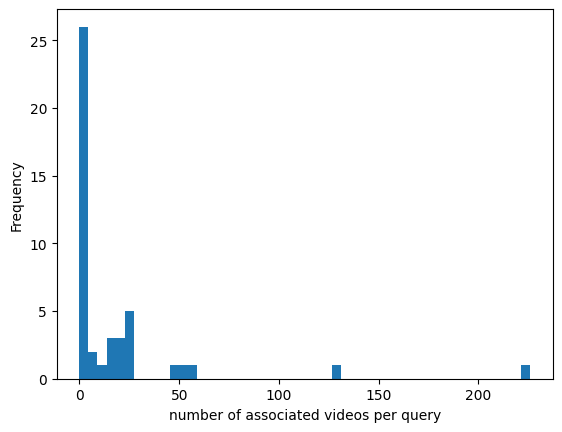

In [38]:
queries_videos_df["nb_videos"].plot(kind="hist", bins=50)
plt.xlabel("number of associated videos per query")
plt.show()